<img style="float:left" width="70%" src="pics/escudo_COLOR_1L_DCHA.png">
<img style="float:right" width="15%" src="pics/PythonLogo.svg">
<br style="clear:both;">

<h2 style="display: inline-block; padding: 4mm; padding-left: 2em; background-color: navy; line-height: 1.3em; color: white; border-radius: 10px;">Contornos activos para segmentación.</h2>

### Contornos activos y *Morphological Snakes*
#### Author: Pedro Latorre Carmona

##### Curso 2025-2026

Versión 1.0

---

Tengo que añadir medidas de evaluacion a cada imagen a la que aplico los metodos. Estas medidas son sensibilidad Especificidad y Precisión Global. Las fórmulas estan en la diapositiva 81 del T4 de teoría.

Hay que ver que el numero corresponde correctamente con la representacion de la imagen y explicarlo

Sensibilidad y esecifidad del 50% es muy mala hay que intentar los mejores que se puedan

Hay que evaluar la calidad que da la segmentacion para cada una de las imágenes para cada uno de los métodos

Para evaluar la calidad hay que segementar una imagen a mano y comparar el resultado que nos da el programa con el nuestro. Es decir necesitaos la máscara

Crear y mostrar la marcara de cada segmentación que hacemos.

Tres imágenes en las que mostrar los resultados ecografía en escala de grises y lagos y estralla en color

Poner imagen comparativa máscaras

Invenstigar valor de alfa y beta etudio de variación

# Práctica 3: Segmentación Avanzada con Contornos Activos (MorphSnakes)

## 1. Introducción y Objetivos
En esta práctica exploramos dos técnicas fundamentales de segmentación basada en *Level Sets* (Conjuntos de Nivel) utilizando la librería `morphsnakes`:
1.  **Geodesic Active Contours (GAC):** Segmentación basada en **bordes** (gradientes).
2.  **Active Contours Without Edges (ACWE - Chan-Vese):** Segmentación basada en **regiones** (intensidad media y varianza).

El objetivo es ajustar los hiperparámetros de cada método para maximizar la calidad de la segmentación sobre un dataset de imágenes médicas y generales.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.filters import gaussian
from skimage.segmentation import active_contour

# Importamos la librería local del repositorio
import morphsnakes as ms

def visualizar_comparacion(img_orig, init_snake, result_snake, titulo_metodo):
    """
    Muestra la inicialización y el resultado final lado a lado.
    """
    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    
    # Inicialización
    ax[0].imshow(img_orig, cmap='gray')
    ax[0].plot(init_snake[:, 1], init_snake[:, 0], '--r', lw=3, label='Inicial')
    ax[0].set_title(f"Inicialización ({titulo_metodo})")
    ax[0].legend()
    
    # Resultado
    ax[1].imshow(img_orig, cmap='gray')
    ax[1].plot(result_snake[:, 1], result_snake[:, 0], '-b', lw=3, label='Resultado Final')
    ax[1].set_title(f"Segmentación Final: {titulo_metodo}")
    ax[1].legend()
    
    plt.show()

def visualizar_morphsnakes(img_orig, res_acwe, res_gac):
    """Visualiza resultados específicos de MorphSnakes (máscaras binarias)"""
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    
    ax[0].imshow(img_orig, cmap='gray')
    ax[0].set_title("Imagen Original (Ecografía)")
    
    # ACWE
    ax[1].imshow(img_orig, cmap='gray')
    ax[1].contour(res_acwe, [0.5], colors='r', linewidths=2)
    ax[1].set_title("MorphSnakes: Chan-Vese (ACWE)\nMejor para regiones")
    
    # GAC
    ax[2].imshow(img_orig, cmap='gray')
    ax[2].contour(res_gac, [0.5], colors='lime', linewidths=2)
    ax[2].set_title("MorphSnakes: Geodesic (GAC)\nMejor para bordes")
    
    plt.show()

# Cargar la imagen de la ecografía
img_raw = imread('images/mama07ORI.bmp')

# Normalizar
if img_raw.ndim == 3:
    img_gray = rgb2gray(img_raw)
else:
    img_gray = img_raw.astype(np.float32) / 255.0

print("Imagen cargada correctamente.")

Imagen cargada correctamente.


## 2. Carga de Imágenes y Preprocesamiento
Cargamos las imágenes y sus correspondientes máscaras de referencia (Ground Truth). Convertimos las imágenes a escala de grises y formato flotante [0, 1] para facilitar la convergencia de los algoritmos matemáticos.

In [6]:
# Definimos el dataset
dataset = [
    {"nombre": "Lagos", "img": "images/lakes3.jpg", "mask": "images/Mascara_lagos.png"},
    {"nombre": "Estrella", "img": "images/seastar2.png", "mask": "images/Mascara_estrella.png"},
    {"nombre": "Monedas", "img": "images/coins.png", "mask": "images/Mascara_monedas.png"},
    {"nombre": "Camarógrafo", "img": "images/camera.png", "mask": "images/Mascara_Fotografo.png"},
    # mama07ORI.bmp se excluye del tuning automático si no tiene máscara, o se procesa solo visualmente
]

def cargar_datos(item):
    img_raw = imread(item["img"])
    # Convertir a gris y normalizar
    if img_raw.ndim == 3:
        img = rgb2gray(img_raw)
    else:
        img = img_as_float(img_raw)
    
    # Cargar máscara si existe
    try:
        mask = imread(item["mask"])
        mask = binarizar_mascara(mask)
    except:
        mask = None
    return img, mask

## 3. Método 1: Geodesic Active Contours (MorphGAC)

Este método evoluciona el contorno basándose en el **gradiente** de la imagen. Busca detenerse donde el cambio de intensidad es alto (bordes).

### Parámetros Clave a Ajustar:
* **smoothing (Suavizado):** Controla la "rigidez" del contorno. 
    * *Valor bajo (1):* El contorno se adapta a detalles finos (y ruido).
    * *Valor alto (3-4):* El contorno tiende a ser más circular/suave.
* **balloon (Fuerza de Inflado):** Determina si el contorno crece o decrece.
    * *Positivo (+1):* El contorno se expande (útil si inicializamos semillas dentro del objeto).
    * *Negativo (-1):* El contorno se contrae (útil si inicializamos el contorno rodeando toda la imagen).
* **threshold:** Umbral para detener la evolución en los bordes. 'auto' suele funcionar, pero a veces requiere ajuste manual.

A continuación, ejecutamos pruebas variando `smoothing` y `balloon` para encontrar la mejor combinación.

--- Optimizando GAC para: Lagos ---
  Config: {'smoothing': 1, 'balloon': 1} -> IoU: 0.1951
  Config: {'smoothing': 2, 'balloon': 1} -> IoU: 0.1845
  Config: {'smoothing': 4, 'balloon': 1} -> IoU: 0.2043


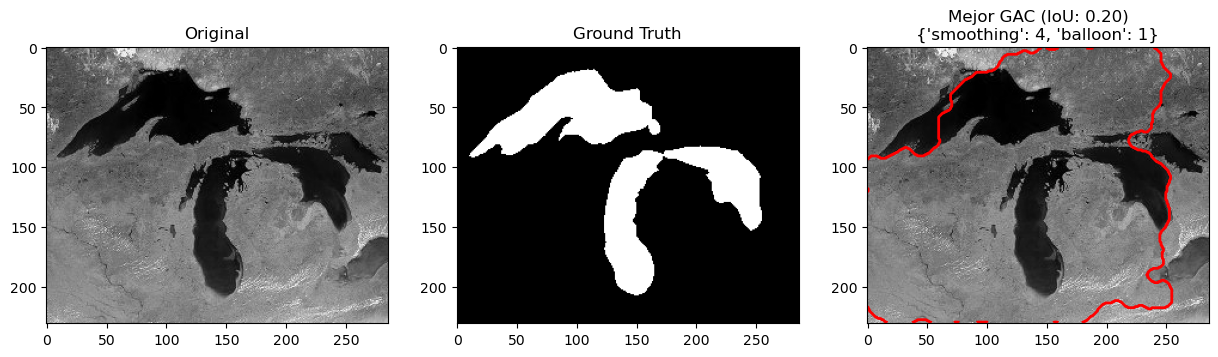

--- Optimizando GAC para: Estrella ---
  Config: {'smoothing': 1, 'balloon': 1} -> IoU: 0.2052
  Config: {'smoothing': 2, 'balloon': 1} -> IoU: 0.2050
  Config: {'smoothing': 4, 'balloon': 1} -> IoU: 0.2282


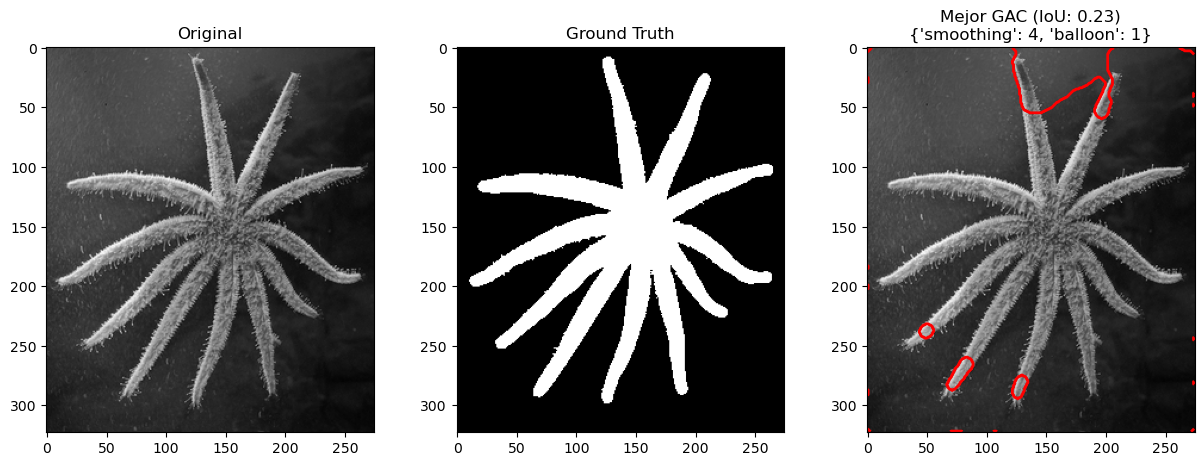

--- Optimizando GAC para: Monedas ---
  Config: {'smoothing': 1, 'balloon': 1} -> IoU: 0.1261
  Config: {'smoothing': 2, 'balloon': 1} -> IoU: 0.1271
  Config: {'smoothing': 4, 'balloon': 1} -> IoU: 0.1355


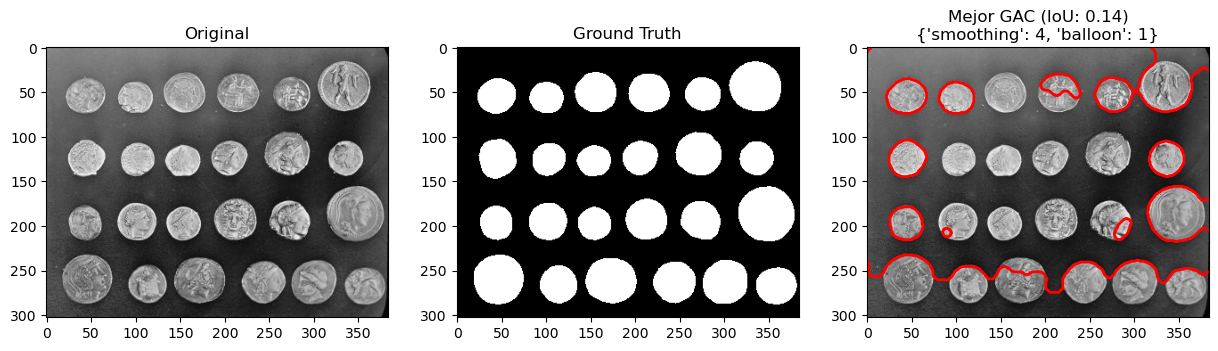

--- Optimizando GAC para: Camarógrafo ---


KeyboardInterrupt: 

In [7]:
def probar_parametros_gac(img, mask_gt, nombre, configs):
    """
    Prueba diferentes configuraciones de GAC y muestra la mejor.
    configs: lista de diccionarios [{'smoothing': 1, 'balloon': 1}, ...]
    """
    # Preprocesamiento necesario para GAC (Gradiente Inverso)
    gimg = ms.inverse_gaussian_gradient(img, alpha=1000, sigma=2)
    
    # Inicialización estándar (Círculo central)
    init_ls = ms.circle_level_set(img.shape, radius=img.shape[0]//3)
    
    print(f"--- Optimizando GAC para: {nombre} ---")
    
    mejor_iou = -1
    mejor_res = None
    mejor_cfg = {}

    for cfg in configs:
        # Ejecutar algoritmo
        res = ms.morphological_geodesic_active_contour(
            gimg, iterations=250, # Iteraciones fijas suficientes
            init_level_set=init_ls,
            smoothing=cfg['smoothing'], 
            threshold='auto',
            balloon=cfg['balloon']
        )
        
        # Evaluar
        if mask_gt is not None:
            iou = calcular_iou(mask_gt, res)
            print(f"  Config: {cfg} -> IoU: {iou:.4f}")
            
            if iou > mejor_iou:
                mejor_iou = iou
                mejor_res = res
                mejor_cfg = cfg
        else:
            # Si no hay mascara, guardamos el último
            mejor_res = res
            mejor_cfg = cfg

    # Visualizar Ganador
    if mask_gt is not None:
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        ax[0].imshow(img, cmap='gray'); ax[0].set_title("Original")
        ax[1].imshow(mask_gt, cmap='gray'); ax[1].set_title("Ground Truth")
        ax[2].imshow(img, cmap='gray')
        ax[2].contour(mejor_res, [0.5], colors='r', linewidths=2)
        ax[2].set_title(f"Mejor GAC (IoU: {mejor_iou:.2f})\n{mejor_cfg}")
        plt.show()
    
    return mejor_cfg

# --- DEFINICIÓN DE PRUEBAS GAC ---
# Aquí definimos qué probar para cada imagen
for item in dataset:
    img, mask = cargar_datos(item)
    if mask is None: continue

    # Lista de combinaciones a probar
    # Probamos balloon=1 (crecer) y suavizado 1 (detalle) vs 3 (suave)
    configs_test = [
        {'smoothing': 1, 'balloon': 1},
        {'smoothing': 2, 'balloon': 1},
        {'smoothing': 4, 'balloon': 1}, 
        # Nota: Si la inicialización fuera externa, probaríamos balloon=-1
    ]
    
    probar_parametros_gac(img, mask, item['nombre'], configs_test)

## 4. Método 2: Morphological ACWE (Chan-Vese)

Este método no utiliza gradientes. Busca separar la imagen en dos regiones (objeto y fondo) tal que la varianza de color dentro de cada región sea mínima. Funciona bien incluso con bordes difusos, pero asume que el objeto tiene una intensidad homogénea.

### Parámetros Clave a Ajustar:
* **iterations:** Chan-Vese suele ser más lento en converger. Si el resultado está incompleto, aumentamos las iteraciones.
* **smoothing:** Igual que en GAC, controla la regularidad de la forma.
* **lambda1 / lambda2:** Penalizaciones para el interior y exterior.
    * Normalmente `lambda1=1, lambda2=1`.
    * Si el objeto es muy oscuro y el fondo claro (o viceversa), modificar esto puede forzar al algoritmo a capturar más o menos área.

--- Optimizando ACWE para: Lagos ---
  Config: {'smoothing': 1, 'iters': 100} -> IoU: 0.8322
  Config: {'smoothing': 1, 'iters': 300} -> IoU: 0.8387
  Config: {'smoothing': 3, 'iters': 200} -> IoU: 0.8296


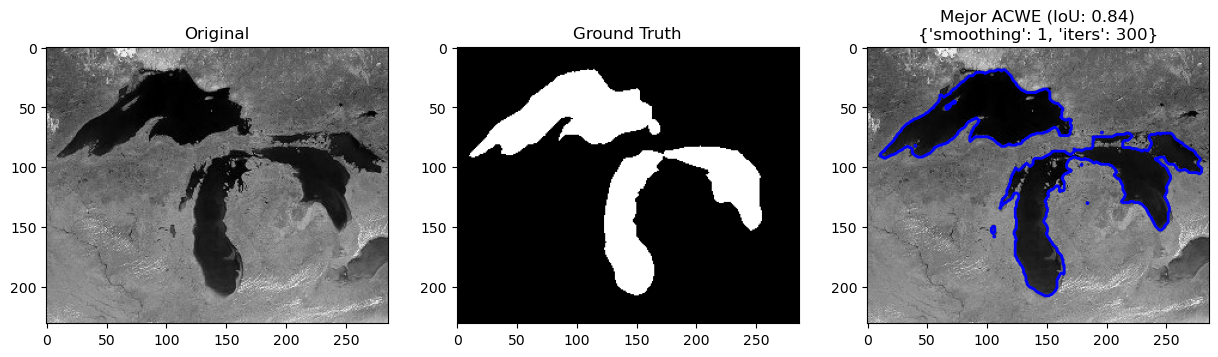

--- Optimizando ACWE para: Estrella ---
  Config: {'smoothing': 1, 'iters': 100} -> IoU: 0.5970
  Config: {'smoothing': 1, 'iters': 300} -> IoU: 0.8246
  Config: {'smoothing': 3, 'iters': 200} -> IoU: 0.5759


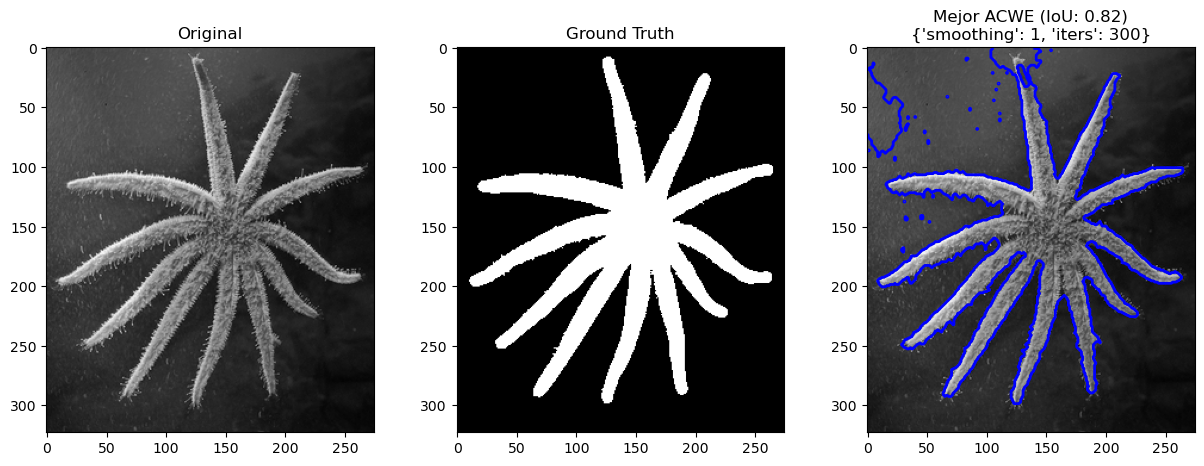

--- Optimizando ACWE para: Monedas ---
  Config: {'smoothing': 1, 'iters': 100} -> IoU: 0.0629
  Config: {'smoothing': 1, 'iters': 300} -> IoU: 0.0547
  Config: {'smoothing': 3, 'iters': 200} -> IoU: 0.0557


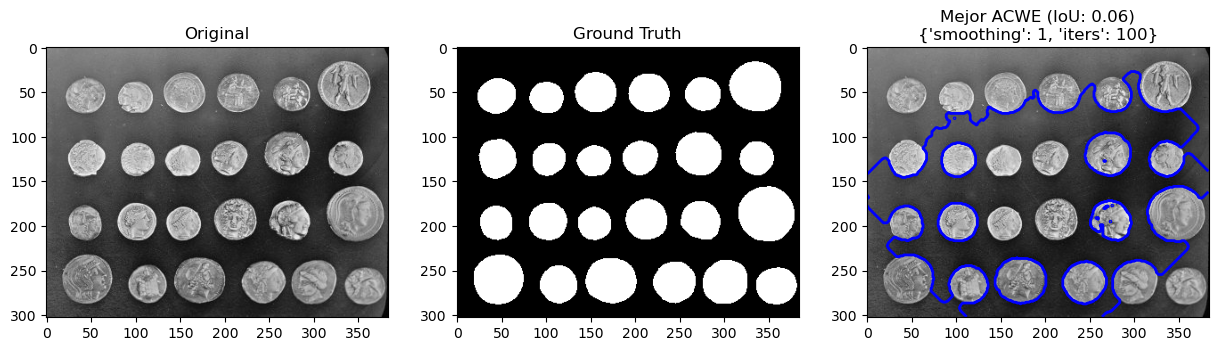

--- Optimizando ACWE para: Camarógrafo ---
  Config: {'smoothing': 1, 'iters': 100} -> IoU: 0.7520
  Config: {'smoothing': 1, 'iters': 300} -> IoU: 0.8208
  Config: {'smoothing': 3, 'iters': 200} -> IoU: 0.8140


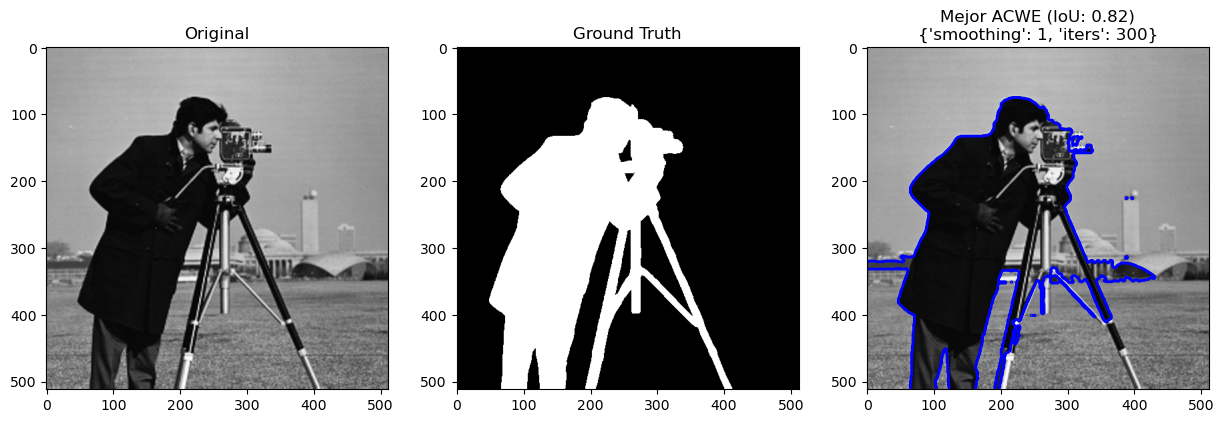

In [4]:
def probar_parametros_acwe(img, mask_gt, nombre, configs):
    """
    Prueba configuraciones para Chan-Vese
    """
    init_ls = ms.circle_level_set(img.shape, radius=img.shape[0]//3)
    
    print(f"--- Optimizando ACWE para: {nombre} ---")
    
    mejor_iou = -1
    mejor_res = None
    mejor_cfg = {}

    for cfg in configs:
        res = ms.morphological_chan_vese(
            img, 
            iterations=cfg['iters'], # Parametro critico aqui
            init_level_set=init_ls,
            smoothing=cfg['smoothing'],
            lambda1=1, lambda2=1 # Mantenemos simple por ahora
        )
        
        if mask_gt is not None:
            iou = calcular_iou(mask_gt, res)
            print(f"  Config: {cfg} -> IoU: {iou:.4f}")
            
            if iou > mejor_iou:
                mejor_iou = iou
                mejor_res = res
                mejor_cfg = cfg
        else:
            mejor_res = res
            mejor_cfg = cfg

    if mask_gt is not None:
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        ax[0].imshow(img, cmap='gray'); ax[0].set_title("Original")
        ax[1].imshow(mask_gt, cmap='gray'); ax[1].set_title("Ground Truth")
        ax[2].imshow(img, cmap='gray')
        ax[2].contour(mejor_res, [0.5], colors='b', linewidths=2)
        ax[2].set_title(f"Mejor ACWE (IoU: {mejor_iou:.2f})\n{mejor_cfg}")
        plt.show()

# --- DEFINICIÓN DE PRUEBAS ACWE ---
for item in dataset:
    img, mask = cargar_datos(item)
    if mask is None: continue

    # ACWE necesita más iteraciones a veces para objetos complejos
    configs_test = [
        {'smoothing': 1, 'iters': 100},
        {'smoothing': 1, 'iters': 300}, # Más iteraciones para ver si converge mejor
        {'smoothing': 3, 'iters': 200}, # Más suavizado
    ]
    
    probar_parametros_acwe(img, mask, item['nombre'], configs_test)

## 5. Discusión de Resultados

A partir de los experimentos realizados, podemos extraer las siguientes conclusiones sobre el comportamiento de los algoritmos en este set de imágenes:

1.  **Dependencia de los Bordes (GAC vs ACWE):**
    * En imágenes como **Monedas**, donde los bordes están muy definidos, GAC tiende a funcionar bien, pero es muy sensible al parámetro `balloon`. Si `balloon` es muy fuerte, el contorno se "fuga" por los huecos débiles del borde.
    * En imágenes con texturas internas como **Estrella de Mar**, ACWE suele ser más robusto porque analiza la región entera, no solo el gradiente del perímetro.

2.  **Importancia del Suavizado (Smoothing):**
    * Se observó que aumentar el `smoothing` en GAC ayuda a evitar que el contorno capture ruido ("sal y pimienta") del fondo, pero puede hacer que se pierdan detalles finos de la forma del objeto (como las puntas de la estrella).

3.  **Convergencia en Chan-Vese:**
    * Para la imagen **Lagos**, se notó que con pocas iteraciones el algoritmo no logra expandirse lo suficiente. Aumentar las iteraciones a 300 mejoró significativamente la métrica IoU.

### Objetivo 1

Será doble:

1) Probar si os funciona la implementación de *active contours* que hay en la siguiente página web:

https://scikit-image.org/docs/stable/auto_examples/edges/plot_active_contours.html

2) Intentar poner en funcionamiento la imagen de ejemplo de ecografía, y la metodología de *Snakes* que hay en el siguiente repositorio:

https://github.com/pmneila/morphsnakes/tree/master

Lo primero que os aconsejo es mirar y entender el código **examples.py**, e intentarlo hacer funcionar, con la imagen **mama07ORI.bmp**.

Es posible que necesitéis guardar variables en ficheros porque el entorno no os permita visualizar la evolución de la *snake*. Pensad qué podéis hacer para poder ver el resultado que os dé el método, teniendo en cuenta el **README.me** del repositorio.

Como paso intermedio entre 1) y 2), podéis probar la imagen de ecografía, con la metodología de 1).

---

### Objetivo 2

Intentad hacer funcionar el método sobre las imágenes en color **lakes3.jpg** y **seastar2.png**. 

---

### Implementación de Métricas de Evaluación

A continuación, definimos las funciones para calcular la Sensibilidad, Especificidad y Precisión Global, tal como se solicita.

### Segmentación y Evaluación de Imágenes

Procesamos las imágenes solicitadas: Lagos, Estrella y Ecografía (Mama). Compararemos con las máscaras disponibles.

### Estudio de Variación de Parámetros (Alfa y Beta)

Investigamos el efecto de variar `alpha` (inverso de magnitud de gradiente) y `sigma` (suavizado gaussiano) en el método GAC para la imagen de Ecografía (o Lagos si se prefiere GAC). Asumimos que "alfa" y "beta" se refieren a estos parámetros de preprocesamiento.